# Libraries

In [1]:
#os.chdir('/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/src')

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import wandb

# Losses Plots

In [3]:
model_list = ["STAINet","PSTAINet-IB","PSTAINet-ILB","PSTAINet-ILRB"]

In [4]:
entity, project = "gsartor-unito", "ST_MultiPoint"

run_names = ["ST_MultiPoint_STNet_SAGW_S_ref",
             "ST_MultiPoint_STDisNet_SAGW_K_S_ref",
             "ST_MultiPoint_STDisNet_SAGW_K_PI_S_ref",
             "ST_MultiPoint_STDisNet_SAGW_K_PI_RCH_S_ref"]

run_ids_train_test = [
           "ycby9xlf",
           "5pz2w0hk",
           "d87emnlm",
           "tlpbljwt"
           ]

# run_ids_train_val = [
#            "ajhj18z9",
#            "tgxer84i",
#            "zd2fo2ya",
#            "h383ul52"
#            ]

run_ids_train_val = [
           "2pswo2p0",
           "umd13ecy",
           "9nb7p0h0",
           "dwgizusk"
           ]

metrics_keys = ["Training_Total_loss",
 "COH_loss",
 "CP_Diff_loss",
 "RCH_loss",
 "Test_data_loss",
 "tr_epoch_exec_t",
 "test_epoch_exec_t"]

In [5]:
main_path = "/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/losses"

In [6]:
def download_parquet_wandb_run(entity, project,
                               run_ids_list, save_dir,
                               page_size = 25000):
    # if not possible to download from wandb this restore the history and save a parquet file -- sometimes some point is lost
    
    for i in range(len(run_ids_list)):
        
        api = wandb.Api(timeout=100)
        print(f"Start looking at run: {run_ids_list[i]}", end = " - ")
        run = api.run(f"{entity}/{project}/{run_ids_list[i]}")
        rows=[]
        
        print(f"Downloading ...", end = " ")
        for row in tqdm(run.scan_history(page_size=page_size)):
            rows.append(row)
        
        df = pd.DataFrame(rows)
        
        df.to_parquet(f"{save_dir}/run-{run_ids_list[i]}-history.parquet")
        print(f"Saved!")

In [7]:
# To download artifacts
# download_parquet_wandb_run(entity, project,
#                            run_ids_train_test,
#                            save_dir = f"{main_path}/data/train_test",
#                            page_size = 2500)

In [8]:
# To download artifacts
# download_parquet_wandb_run(entity, project,
#                            run_ids_train_val,
#                            save_dir = f"{main_path}/data/train_validation")

In [9]:
run_metrics_train_test = {}
run_metrics_train_validation = {}

for i in range(len(model_list)):    
    temp_ds_metrics_tt = pd.read_parquet(f"/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/losses/data/train_test/run-{run_ids_train_test[i]}-history.parquet")
    temp_ds_metrics_tv = pd.read_parquet(f"/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/losses/data/train_validation/run-{run_ids_train_val[i]}-history.parquet")
    
    sel_metrics_tt = list(temp_ds_metrics_tt.columns[temp_ds_metrics_tt.columns.isin(metrics_keys)])
    sel_metrics_tv = list(temp_ds_metrics_tv.columns[temp_ds_metrics_tv.columns.isin(metrics_keys)])
    
    run_metrics_train_test[model_list[i]] = temp_ds_metrics_tt.loc[:,sel_metrics_tt]
    run_metrics_train_validation[model_list[i]] = temp_ds_metrics_tv.loc[:,sel_metrics_tv]

In [10]:
run_metrics_train_validation["STAINet"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('STAINet')

0        0.908922
1        0.917791
2        0.856213
3        0.845638
4        0.851981
           ...   
30995    0.011572
30996    0.011347
30997    0.009742
30998    0.009762
30999    0.010395
Name: STAINet, Length: 31000, dtype: float64

In [11]:
run_metrics_train_test['STAINet']["Training_Total_loss"].dropna().reset_index(drop = True).rename('STAINet')

0        0.897796
1        0.892773
2        0.877410
3        0.865716
4        0.829960
           ...   
33995    0.010341
33996    0.009118
33997    0.009725
33998    0.009994
33999    0.009133
Name: STAINet, Length: 34000, dtype: float64

In [12]:
plot_save_path = '/leonardo_scratch/fast/IscrC_DL4STP/physics-guided-gwl/results/plot/losses'

In [14]:
run_metrics_train_test["STAINet"]

,Training_Total_loss,tr_epoch_exec_t,test_epoch_exec_t,Test_data_loss
0,NaN,NaN,NaN,NaN
1,0.897796,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,0.892773,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
73995,NaN,NaN,NaN,0.014958
73996,NaN,NaN,NaN,0.020810
73997,NaN,NaN,NaN,0.017179
73998,NaN,NaN,NaN,0.012025


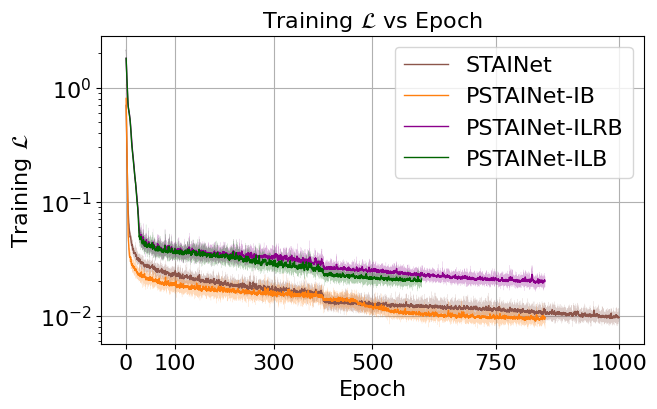

In [15]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})

fig, ax = plt.subplots(figsize = (7,4))
train_tot_los = pd.concat([
         run_metrics_train_test["STAINet"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('STAINet'),
         run_metrics_train_test["PSTAINet-IB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-IB'),
         run_metrics_train_test["PSTAINet-ILRB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_test["PSTAINet-ILB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer")
train_tot_los.plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax)
train_tot_los.rolling(34, center=True).mean().plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-4:], labels[-4:], fontsize=16)
plt.ylabel(r"Training $\mathcal{{L}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3400,10200,17000,25500,34000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}$ vs Epoch", fontsize=16)
plt.yscale("log")

plt.savefig(f"{plot_save_path}/train_test/tot_train_loss_corrected.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

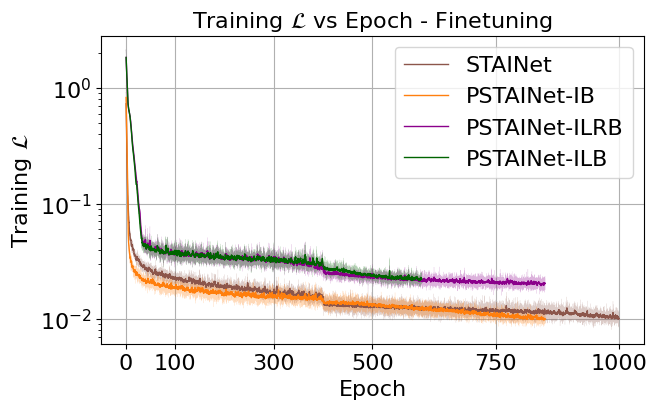

In [16]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})

fig, ax = plt.subplots(figsize = (7,4))
train_tot_los = pd.concat([
         run_metrics_train_validation["STAINet"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('STAINet'),
         run_metrics_train_validation["PSTAINet-IB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-IB'),
         run_metrics_train_validation["PSTAINet-ILRB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_validation["PSTAINet-ILB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer")
train_tot_los.plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax)
train_tot_los.rolling(31, center=True).mean().plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-4:], labels[-4:], fontsize=16)
plt.ylabel(r"Training $\mathcal{{L}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3100,9300,15500,23250,31000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}$ vs Epoch - Finetuning", fontsize=16)
plt.yscale("log")

plt.savefig(f"{plot_save_path}/train_validation/2y/tot_train_loss_ft_corrected.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

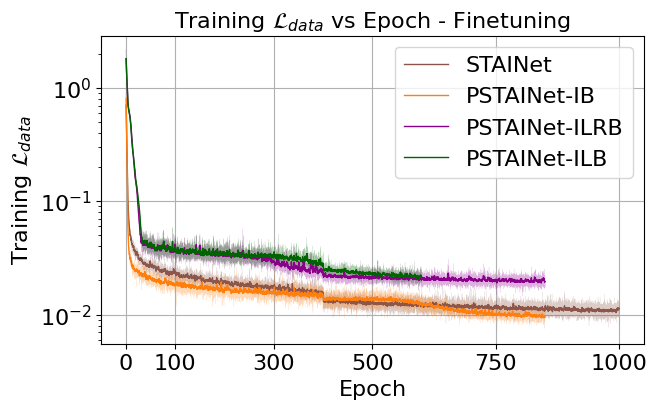

In [ ]:
# plt.rcParams.update({'font.size': 16,
#                          'ytick.labelsize': 16,
#                          'xtick.labelsize': 16})

# fig, ax = plt.subplots(figsize = (7,4))
# train_tot_los = pd.concat([
#          run_metrics_train_validation["STAINet"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('STAINet'),
#          run_metrics_train_validation["PSTAINet-IB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-IB'),
#          run_metrics_train_validation["PSTAINet-ILRB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
#          run_metrics_train_validation["PSTAINet-ILB"]["Training_Total_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
#          axis=1, join = "outer")
# train_tot_los.plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax)
# train_tot_los.rolling(33, center=True).mean().plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 1, ax = ax)
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[-4:], labels[-4:], fontsize=16)
# plt.ylabel(r"Training $\mathcal{{L}}_{{data}}$", fontsize=16)
# plt.xlabel("Epoch", fontsize=16)
# plt.xticks([0,3300,9900,16500,24750,33000],[0,100,300,500,750,1000])
# plt.grid()
# plt.title(r"Training $\mathcal{{L}}_{{data}}$ vs Epoch - Finetuning", fontsize=16)
# plt.yscale("log")

#plt.savefig(f"{plot_save_path}/train_validation/tot_train_loss_ft.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

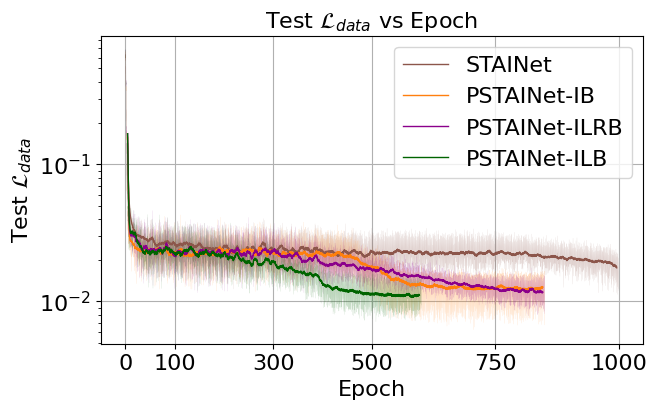

In [44]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})

fig, ax = plt.subplots(figsize = (7,4))
test_tot_los = pd.concat([
         run_metrics_train_test["STAINet"]["Test_data_loss"].dropna().reset_index(drop = True).rename('STAINet'),
         run_metrics_train_test["PSTAINet-IB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-IB'),
         run_metrics_train_test["PSTAINet-ILRB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_test["PSTAINet-ILB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer", names = ["a","b"])
test_tot_los.plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
test_tot_los.rolling(34, center=True).mean().plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-4:], labels[-4:], fontsize=16)
plt.ylabel(r"Test $\mathcal{{L}}_{{data}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,400,1200,2000,3000,4000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Test $\mathcal{{L}}_{{data}}$ vs Epoch", fontsize=16)
plt.yscale("log")
#plt.savefig(f"{plot_save_path}/train_test/tot_test_loss.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

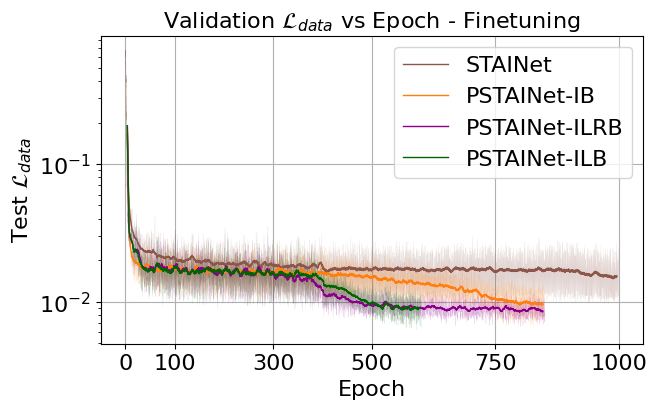

In [23]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})

fig, ax = plt.subplots(figsize = (7,4))
test_tot_los = pd.concat([
         run_metrics_train_validation["STAINet"]["Test_data_loss"].dropna().reset_index(drop = True).rename('STAINet'),
         run_metrics_train_validation["PSTAINet-IB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-IB'),
         run_metrics_train_validation["PSTAINet-ILRB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_validation["PSTAINet-ILB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer", names = ["a","b"])
test_tot_los.plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
test_tot_los.rolling(31, center=True).mean().plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-4:], labels[-4:], fontsize=16)
plt.ylabel(r"Test $\mathcal{{L}}_{{data}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,400,1200,2000,3000,4000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Validation $\mathcal{{L}}_{{data}}$ vs Epoch - Finetuning", fontsize=16)
plt.yscale("log")

plt.savefig(f"{plot_save_path}/train_validation/2y/tot_test_loss_ft.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

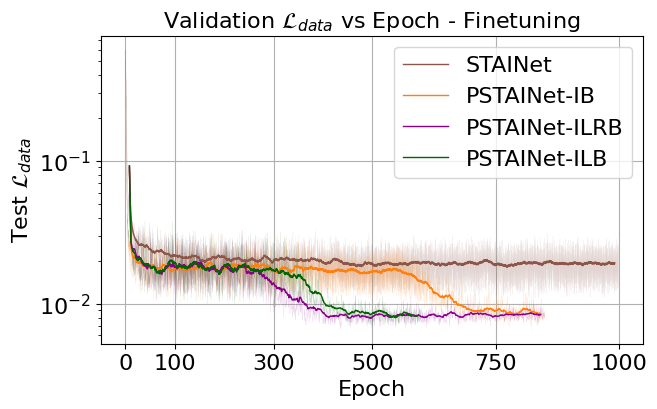

In [ ]:
# plt.rcParams.update({'font.size': 16,
#                          'ytick.labelsize': 16,
#                          'xtick.labelsize': 16})

# fig, ax = plt.subplots(figsize = (7,4))
# test_tot_los = pd.concat([
#          run_metrics_train_validation["STAINet"]["Test_data_loss"].dropna().reset_index(drop = True).rename('STAINet'),
#          run_metrics_train_validation["PSTAINet-IB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-IB'),
#          run_metrics_train_validation["PSTAINet-ILRB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
#          run_metrics_train_validation["PSTAINet-ILB"]["Test_data_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
#          axis=1, join = "outer", names = ["a","b"])
# test_tot_los.plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
# test_tot_los.rolling(33, center=True).mean().plot(color = ["tab:brown","tab:orange","darkmagenta","darkgreen"], lw = 1, ax = ax)
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[-4:], labels[-4:], fontsize=16)
# plt.ylabel(r"Test $\mathcal{{L}}_{{data}}$", fontsize=16)
# plt.xlabel("Epoch", fontsize=16)
# plt.xticks([0,200,600,1000,1500,2000],[0,100,300,500,750,1000])
# plt.grid()
# plt.title(r"Validation $\mathcal{{L}}_{{data}}$ vs Epoch - Finetuning", fontsize=16)
# plt.yscale("log")

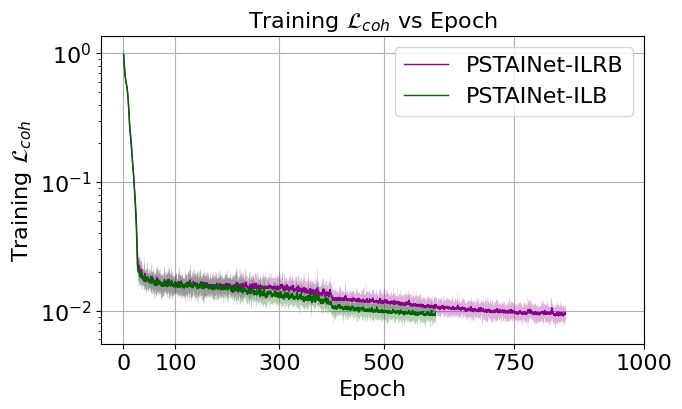

In [47]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})
fig, ax = plt.subplots(figsize = (7,4))
test_tot_los = pd.concat([
         run_metrics_train_test["PSTAINet-ILRB"]["COH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_test["PSTAINet-ILB"]["COH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer", names = ["a","b"])
test_tot_los.plot(color = ["darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
test_tot_los.rolling(34, center=True).mean().plot(color = ["darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], fontsize=16)
plt.ylabel(r"Training $\mathcal{{L}}_{{coh}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3400,10200,17000,25500,34000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}_{{coh}}$ vs Epoch", fontsize=16)
plt.yscale("log")
#plt.savefig(f"{plot_save_path}/train_test/coh_loss.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

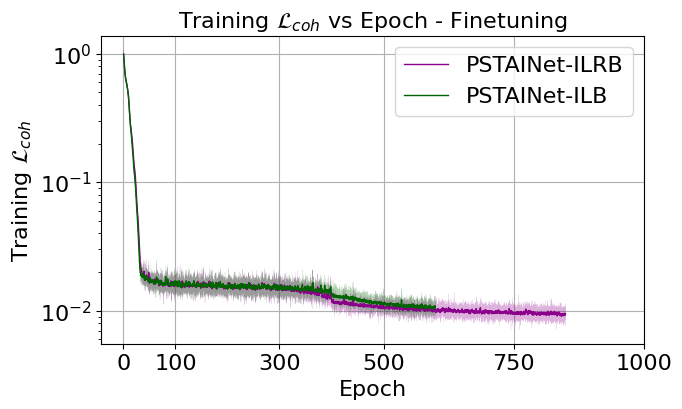

In [27]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})
fig, ax = plt.subplots(figsize = (7,4))
test_tot_los = pd.concat([
         run_metrics_train_validation["PSTAINet-ILRB"]["COH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_validation["PSTAINet-ILB"]["COH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer", names = ["a","b"])
test_tot_los.plot(color = ["darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
test_tot_los.rolling(31, center=True).mean().plot(color = ["darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], fontsize=16)
plt.ylabel(r"Training $\mathcal{{L}}_{{coh}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3100,9300,15500,23250,31000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}_{{coh}}$ vs Epoch - Finetuning", fontsize=16)
plt.yscale("log")

plt.savefig(f"{plot_save_path}/train_validation/2y/coh_loss_ft.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

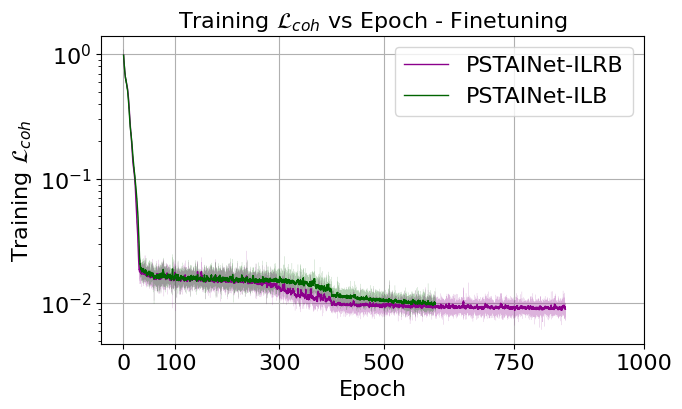

In [ ]:
# plt.rcParams.update({'font.size': 16,
#                          'ytick.labelsize': 16,
#                          'xtick.labelsize': 16})
# fig, ax = plt.subplots(figsize = (7,4))
# test_tot_los = pd.concat([
#          run_metrics_train_validation["PSTAINet-ILRB"]["COH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
#          run_metrics_train_validation["PSTAINet-ILB"]["COH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
#          axis=1, join = "outer", names = ["a","b"])
# test_tot_los.plot(color = ["darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
# test_tot_los.rolling(33, center=True).mean().plot(color = ["darkmagenta","darkgreen"], lw = 1, ax = ax)
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[-2:], labels[-2:], fontsize=16)
# plt.ylabel(r"Training $\mathcal{{L}}_{{coh}}$", fontsize=16)
# plt.xlabel("Epoch", fontsize=16)
# plt.xticks([0,3300,9900,16500,24750,33000],[0,100,300,500,750,1000])
# plt.grid()
# plt.title(r"Training $\mathcal{{L}}_{{coh}}$ vs Epoch - Finetuning", fontsize=16)
# plt.yscale("log")


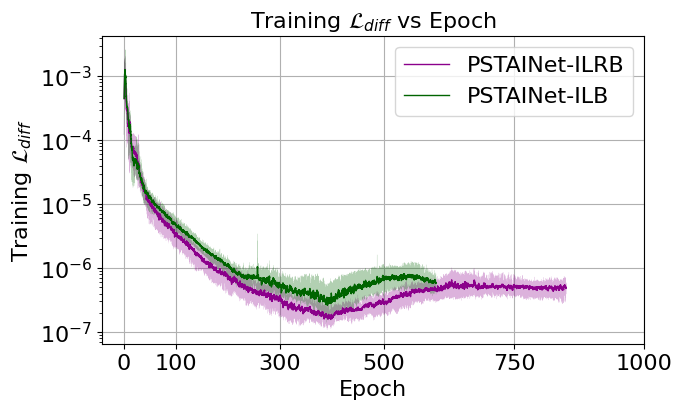

In [51]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})
fig, ax = plt.subplots(figsize = (7,4))
test_tot_los = pd.concat([
         run_metrics_train_test["PSTAINet-ILRB"]["CP_Diff_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_test["PSTAINet-ILB"]["CP_Diff_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer", names = ["a","b"])
test_tot_los.plot(color = ["darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
test_tot_los.rolling(34, center=True).mean().plot(color = ["darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], fontsize=16)
plt.ylabel(r"Training $\mathcal{{L}}_{{diff}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3400,10200,17000,25500,34000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}_{{diff}}$ vs Epoch", fontsize=16)
plt.yscale("log")
#plt.savefig(f"{plot_save_path}/train_test/diff_loss.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

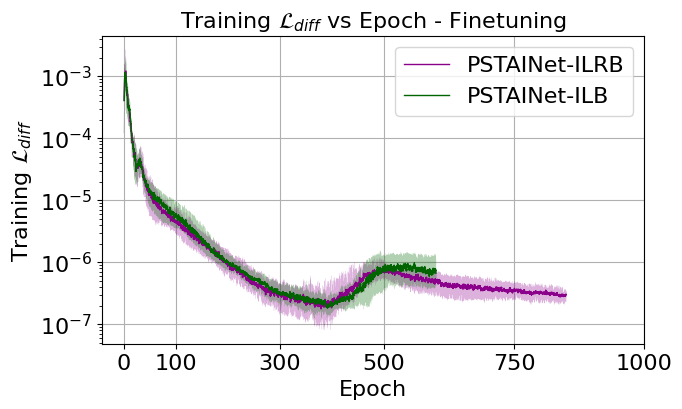

In [26]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})
fig, ax = plt.subplots(figsize = (7,4))
test_tot_los = pd.concat([
         run_metrics_train_validation["PSTAINet-ILRB"]["CP_Diff_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
         run_metrics_train_validation["PSTAINet-ILB"]["CP_Diff_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
         axis=1, join = "outer", names = ["a","b"])
test_tot_los.plot(color = ["darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
test_tot_los.rolling(31, center=True).mean().plot(color = ["darkmagenta","darkgreen"], lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:], fontsize=16)
plt.ylabel(r"Training $\mathcal{{L}}_{{diff}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3100,9300,15500,23250,31000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}_{{diff}}$ vs Epoch - Finetuning", fontsize=16)
plt.yscale("log")

plt.savefig(f"{plot_save_path}/train_validation/2y/diff_loss_ft.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

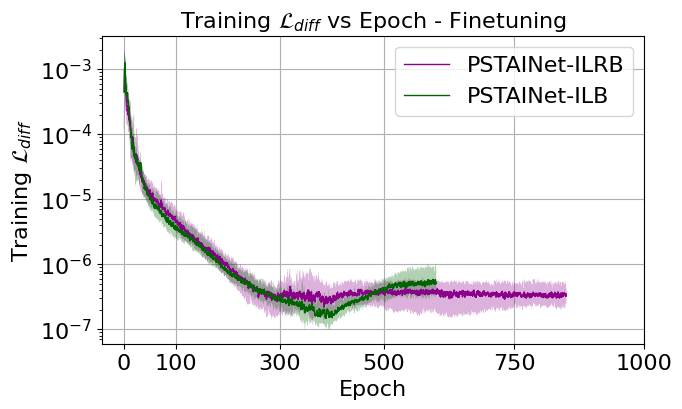

In [ ]:
# plt.rcParams.update({'font.size': 16,
#                          'ytick.labelsize': 16,
#                          'xtick.labelsize': 16})
# fig, ax = plt.subplots(figsize = (7,4))
# test_tot_los = pd.concat([
#          run_metrics_train_validation["PSTAINet-ILRB"]["CP_Diff_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB'),
#          run_metrics_train_validation["PSTAINet-ILB"]["CP_Diff_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILB'),],
#          axis=1, join = "outer", names = ["a","b"])
# test_tot_los.plot(color = ["darkmagenta","darkgreen"], lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
# test_tot_los.rolling(33, center=True).mean().plot(color = ["darkmagenta","darkgreen"], lw = 1, ax = ax)
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[-2:], labels[-2:], fontsize=16)
# plt.ylabel(r"Training $\mathcal{{L}}_{{diff}}$", fontsize=16)
# plt.xlabel("Epoch", fontsize=16)
# plt.xticks([0,3300,9900,16500,24750,33000],[0,100,300,500,750,1000])
# plt.grid()
# plt.title(r"Training $\mathcal{{L}}_{{diff}}$ vs Epoch - Finetuning", fontsize=16)
# plt.yscale("log")

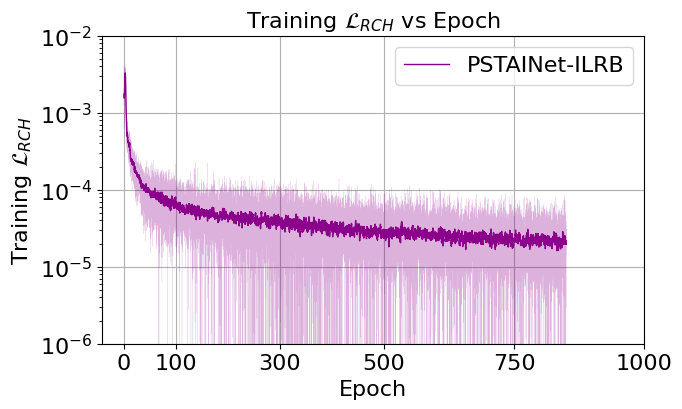

In [54]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})
fig, ax = plt.subplots(figsize = (7,4))
run_metrics_train_test["PSTAINet-ILRB"]["RCH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB').plot(color = "darkmagenta", lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
run_metrics_train_test["PSTAINet-ILRB"]["RCH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB').rolling(34, center=True).mean().plot(color = "darkmagenta", lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-1:], labels[-1:], fontsize=16)
plt.ylim((0.000001,0.01))
plt.ylabel(r"Training $\mathcal{{L}}_{{RCH}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3400,10200,17000,25500,34000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}_{{RCH}}$ vs Epoch", fontsize=16)
plt.yscale("log")
#plt.savefig(f"{plot_save_path}/train_test/rch_loss.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

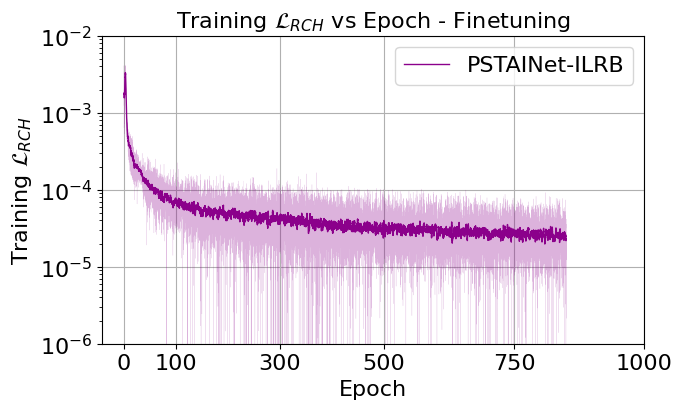

In [28]:
plt.rcParams.update({'font.size': 16,
                         'ytick.labelsize': 16,
                         'xtick.labelsize': 16})
fig, ax = plt.subplots(figsize = (7,4))
run_metrics_train_validation["PSTAINet-ILRB"]["RCH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB').plot(color = "darkmagenta", lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
run_metrics_train_validation["PSTAINet-ILRB"]["RCH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB').rolling(31, center=True).mean().plot(color = "darkmagenta", lw = 1, ax = ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-1:], labels[-1:], fontsize=16)
plt.ylim((0.000001,0.01))
plt.ylabel(r"Training $\mathcal{{L}}_{{RCH}}$", fontsize=16)
plt.xlabel("Epoch", fontsize=16)
plt.xticks([0,3100,9300,15500,23250,31000],[0,100,300,500,750,1000])
plt.grid()
plt.title(r"Training $\mathcal{{L}}_{{RCH}}$ vs Epoch - Finetuning", fontsize=16)
plt.yscale("log")
plt.savefig(f"{plot_save_path}/train_validation/2y/rch_loss_ft.jpg", dpi = 600, transparent = True, bbox_inches = 'tight')

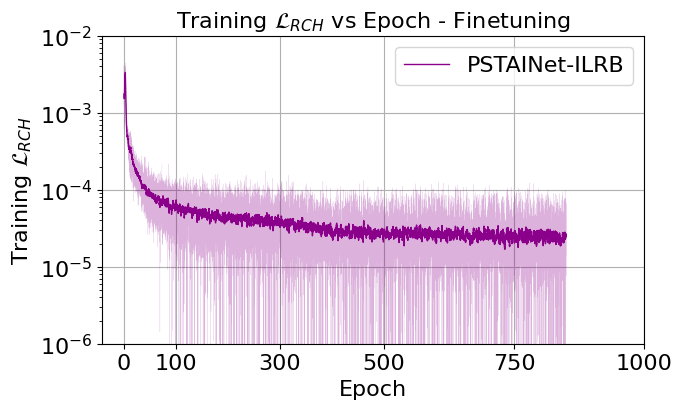

In [ ]:
# plt.rcParams.update({'font.size': 16,
#                          'ytick.labelsize': 16,
#                          'xtick.labelsize': 16})
# fig, ax = plt.subplots(figsize = (7,4))
# run_metrics_train_validation["PSTAINet-ILRB"]["RCH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB').plot(color = "darkmagenta", lw = 0.15, alpha = 0.3,  ax = ax, legend = False)
# run_metrics_train_validation["PSTAINet-ILRB"]["RCH_loss"].dropna().reset_index(drop = True).rename('PSTAINet-ILRB').rolling(33, center=True).mean().plot(color = "darkmagenta", lw = 1, ax = ax)
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[-1:], labels[-1:], fontsize=16)
# plt.ylim((0.000001,0.01))
# plt.ylabel(r"Training $\mathcal{{L}}_{{RCH}}$", fontsize=16)
# plt.xlabel("Epoch", fontsize=16)
# plt.xticks([0,3300,9900,16500,24750,33000],[0,100,300,500,750,1000])
# plt.grid()
# plt.title(r"Training $\mathcal{{L}}_{{RCH}}$ vs Epoch - Finetuning", fontsize=16)
# plt.yscale("log")

## Execution times

In [58]:
tr_exe_time = {}
test_exe_time = {}
for m in model_list:
    tr_exe_time[m] = run_metrics_train_test[m]["tr_epoch_exec_t"].dropna().reset_index(drop = True)
    test_exe_time[m] = run_metrics_train_test[m]["test_epoch_exec_t"].dropna().reset_index(drop = True)
    
tr_exe_time = pd.DataFrame(tr_exe_time)
test_exe_time = pd.DataFrame(test_exe_time)

tr_exe_time[tr_exe_time>30] = np.nan
test_exe_time[tr_exe_time>30] = np.nan

In [89]:
tr_exe_time.mean()

STAINet           4.615997
PSTAINet-IB       4.156876
PSTAINet-ILB     18.286492
PSTAINet-ILRB    18.697248
dtype: float64

In [90]:
test_exe_time.mean()

STAINet          2.282329
PSTAINet-IB      1.927167
PSTAINet-ILB     1.979052
PSTAINet-ILRB    2.013913
dtype: float64